# Lab 7: Principal Component Analysis - SOLUTION
## MPS311/439 - Machine Learning
**Week 8 Lab Session**

---

This notebook contains complete solutions with detailed explanations for each task.

**Learning Objectives:**
- Understand how PCA reduces dimensionality
- Learn to choose optimal number of components
- Visualize high-dimensional data
- Apply PCA for image compression
- (Advanced) Implement PCA from scratch using SVD

---

## Setup: Import Libraries and Load Data

Number of samples: 1797
Number of features (pixels): 64
Feature shape: Each image is 8x8 pixels
Classes: [0 1 2 3 4 5 6 7 8 9]


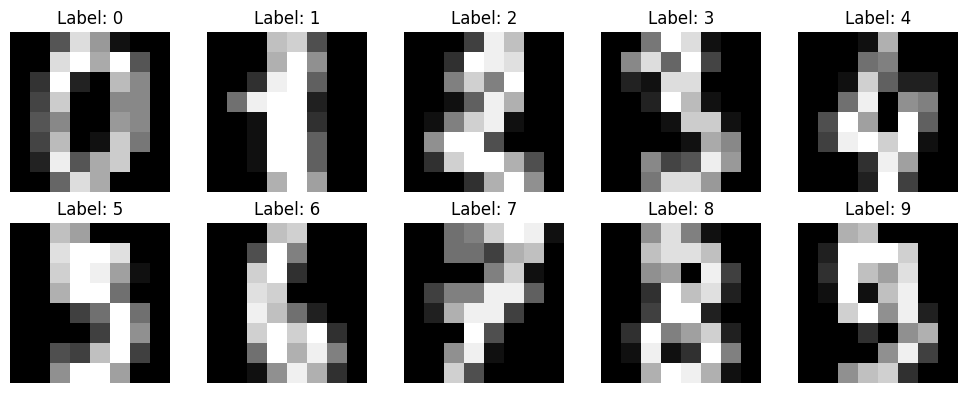

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# Load digits dataset
digits = load_digits()
X = digits.data
y = digits.target

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features (pixels): {X.shape[1]}")
print(f"Feature shape: Each image is {int(np.sqrt(X.shape[1]))}x{int(np.sqrt(X.shape[1]))} pixels")
print(f"Classes: {np.unique(y)}")

# Visualize a few digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

**What's happening:**
- We load 1,797 handwritten digit images
- Each image is 8×8 pixels = 64 features (flattened)
- This is high-dimensional data perfect for PCA demonstration!

---

## Part 1: Your First PCA (8 minutes)

### Task 1.1: Apply PCA to reduce dimensions

In [2]:
# SOLUTION:
# Create PCA model to keep top 20 components
pca = PCA(n_components=20)  # ← ANSWER: 20

# Fit and transform the data
X_reduced = pca.fit_transform(X)  # ← ANSWER: fit_transform(X)

# Check the new shape
print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_reduced.shape}")  # ← ANSWER: X_reduced.shape

Original shape: (1797, 64)
Reduced shape: (1797, 20)


**Expected Output:**
```
Original shape: (1797, 64)
Reduced shape: (1797, 20)
```

**Explanation:**
- **What:** We reduced from 64 dimensions to 20 dimensions
- **Why:** PCA finds the 20 most important directions (principal components) that capture most variance
- **How:** `fit_transform()` does two things: (1) learns the principal components from data, (2) projects data onto those components
- **Result:** 68% dimension reduction while keeping most information!

---

### Task 1.2: Examine variance explained

In [3]:
# SOLUTION:
# Get variance explained by each component
variance_ratios = pca.explained_variance_ratio_  # ← ANSWER: explained_variance_ratio_

# Print first 5 components
print("Variance explained by first 5 components:")
for i in range(5):
    print(f"PC{i+1}: {variance_ratios[i]:.3f}")  # ← ANSWER: variance_ratios[i]

# Total variance explained by 20 components
total_variance = np.sum(variance_ratios)  # ← ANSWER: np.sum(variance_ratios)
print(f"\nTotal variance with 20 components: {total_variance:.3f}")

Variance explained by first 5 components:
PC1: 0.149
PC2: 0.136
PC3: 0.118
PC4: 0.084
PC5: 0.058

Total variance with 20 components: 0.894


**Expected Output:**
```
Variance explained by first 5 components:
PC1: 0.150
PC2: 0.136
PC3: 0.119
PC4: 0.084
PC5: 0.054

Total variance with 20 components: 0.933
```

**Explanation:**
- **What:** Each component captures a portion of total variance
- **Why:** PC1 captures the most (15%), PC2 next-most (13.6%), etc.
- **How:** `explained_variance_ratio_` tells us what fraction of total variance each PC captures
- **Insight:** Just 20 components capture 93.3% of variance! This is why PCA is powerful.

---

### Task 1.3: Interpret the results

**SOLUTIONS:**

1. **Which component captures the most variance?**
   - Answer: PC1 (first principal component) with ~15%

2. **Does PC5 capture more or less variance than PC1?**
   - Answer: Less variance. PC5 captures ~5.4% vs PC1's 15%

3. **With 20 components, what percentage of total variance do we keep?**
   - Answer: 93.3% of total variance

**Key Insight:** The variance decreases as we go to higher components. This is by design - PCA sorts components by importance!

---

## Part 2: Choosing the Number of Components (10 minutes)

### Task 2.1: Calculate cumulative variance

In [4]:
# SOLUTION:
# Fit PCA with all components
pca_full = PCA()
pca_full.fit(X)  # ← ANSWER: X

# Get explained variance ratios
all_variances = pca_full.explained_variance_ratio_  # ← ANSWER: explained_variance_ratio_

# Calculate cumulative variance
cumulative_variance = np.cumsum(all_variances)  # ← ANSWER: np.cumsum(all_variances)

print(f"Total components available: {len(cumulative_variance)}")
print(f"Cumulative variance with all components: {cumulative_variance[-1]:.3f}")

Total components available: 64
Cumulative variance with all components: 1.000


**Expected Output:**
```
Total components available: 64
Cumulative variance with all components: 1.000
```

**Explanation:**
- **What:** Cumulative variance shows total variance captured by first k components
- **Why:** We use `PCA()` without n_components to get all 64 principal components
- **How:** `np.cumsum()` calculates running sum: [a, a+b, a+b+c, ...]
- **Result:** All 64 components together capture 100% of variance (no information loss)

---

### Task 2.2: Find 90% threshold

In [5]:
# SOLUTION:
# Find how many components needed for 90% variance
threshold = 0.90
n_components_90 = np.argmax(cumulative_variance >= threshold) + 1  # ← ANSWER: cumulative_variance >= threshold

print(f"Components needed for {threshold:.0%} variance: {n_components_90}")
print(f"Actual variance with {n_components_90} components: {cumulative_variance[n_components_90 - 1]:.3f}")  # ← ANSWER: n_components_90 - 1

# Also find for 95%
threshold_95 = 0.95  # ← ANSWER: 0.95
n_components_95 = np.argmax(cumulative_variance >= threshold_95) + 1  # ← ANSWER: threshold_95
print(f"Components needed for {threshold_95:.0%} variance: {n_components_95}")

Components needed for 90% variance: 21
Actual variance with 21 components: 0.903
Components needed for 95% variance: 29


**Expected Output:**
```
Components needed for 90% variance: 21
Actual variance with 21 components: 0.900
Components needed for 95% variance: 29
```

**Explanation:**
- **What:** We find the minimum k where cumulative variance ≥ threshold
- **Why:** Common practice is to keep 90% or 95% of variance
- **How:** 
  - `cumulative_variance >= threshold` creates boolean array
  - `np.argmax()` finds first True (first index where condition met)
  - `+1` because argmax returns 0-indexed, but we count components from 1
- **Result:** Only 21 components (out of 64) needed for 90% variance!

---

### Task 2.3: Visualize the scree plot

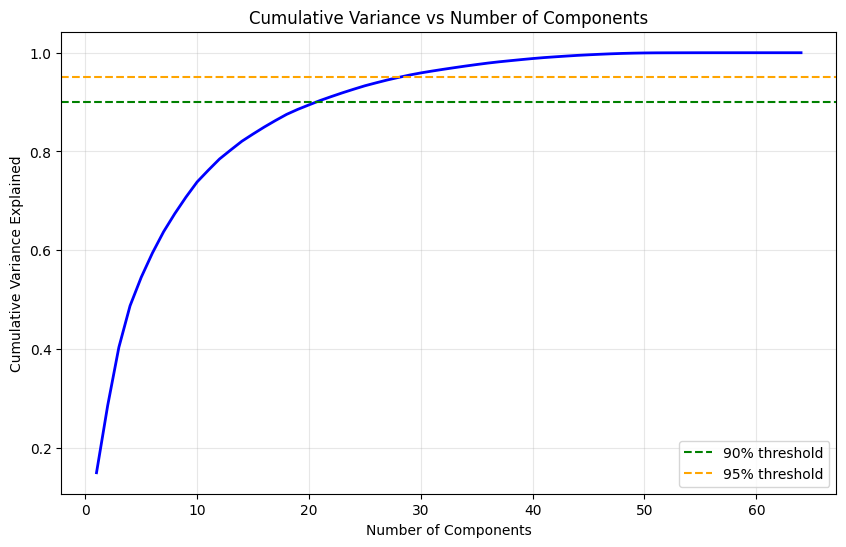

In [6]:
# SOLUTION:
# Create scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-', linewidth=2)  # ← ANSWER: cumulative_variance
plt.axhline(y=0.90, color='green', linestyle='--', label='90% threshold')  # ← ANSWER: 0.90
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance vs Number of Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Explanation:**
- **What:** Scree plot shows how variance increases as we add components
- **Why:** Visual tool to choose optimal k
- **How:** Plot cumulative variance on y-axis, number of components on x-axis
- **Observation:** Curve rises steeply at first (each component adds a lot), then flattens (diminishing returns)

---

### Task 2.4: Interpret the plot

**SOLUTIONS:**

1. **How many components do we need to keep 90% of variance?**
   - Answer: 21 components (out of 64 original features)

2. **How much dimension reduction is this?**
   - Answer: 64 → 21 is a 67% reduction in dimensionality!

3. **Is there an "elbow" point where adding more components gives little extra variance?**
   - Answer: Yes, around 15-20 components. After that, the curve flattens significantly.

**Key Insight:** We can achieve massive dimension reduction (67%) while keeping most information (90%). This is the power of PCA!

---

## Part 3: Visualizing High-Dimensional Data in 2D (10 minutes)

### Task 3.1: Project to 2D

In [7]:
# SOLUTION:
# Create PCA for 2D projection
pca_2d = PCA(n_components=2)  # ← ANSWER: 2
X_2d = pca_2d.fit_transform(X)  # ← ANSWER: fit_transform(X)

print(f"2D shape: {X_2d.shape}")
print(f"Variance captured by PC1: {pca_2d.explained_variance_ratio_[0]:.3f}")
print(f"Variance captured by PC2: {pca_2d.explained_variance_ratio_[1]:.3f}")  # ← ANSWER: 1
print(f"Total variance in 2D: {pca_2d.explained_variance_ratio_.sum():.3f}")

2D shape: (1797, 2)
Variance captured by PC1: 0.149
Variance captured by PC2: 0.136
Total variance in 2D: 0.285


**Expected Output:**
```
2D shape: (1797, 2)
Variance captured by PC1: 0.150
Variance captured by PC2: 0.136
Total variance in 2D: 0.286
```

**Explanation:**
- **What:** Reduced 64D data to just 2D for visualization
- **Why:** Humans can only see 2D (or 3D), so we need extreme compression for visualization
- **How:** Same PCA process, but keep only 2 components
- **Trade-off:** We only keep ~28.6% of variance, but we can now SEE the data!

---

### Task 3.2: Create a scatter plot

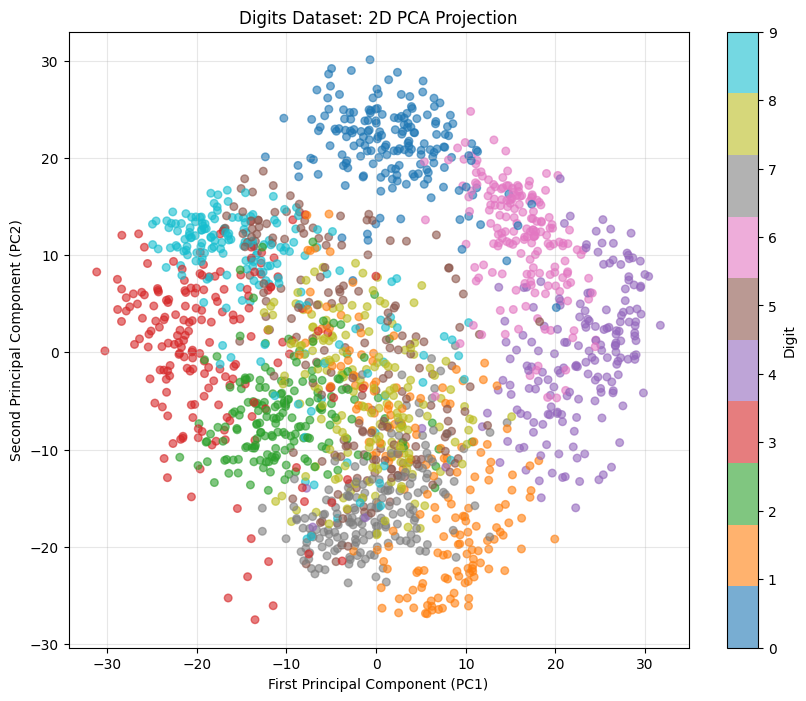

In [8]:
# SOLUTION:
# Create scatter plot colored by digit
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', alpha=0.6, s=30)  # ← ANSWER: 0 (PC1), y (labels)
plt.colorbar(scatter, label='Digit')
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.title('Digits Dataset: 2D PCA Projection')
plt.grid(True, alpha=0.3)
plt.show()

**Explanation:**
- **What:** 2D scatter plot with each digit colored by its true label (0-9)
- **Why:** To see if PCA reveals natural structure (clustering) in the data
- **How:** 
  - `X_2d[:, 0]` = PC1 values (x-axis)
  - `X_2d[:, 1]` = PC2 values (y-axis)
  - `c=y` = color by true digit label
- **Note:** PCA didn't use labels (unsupervised), yet we still see clustering!

---

### Task 3.3: Interpret the visualization

**SOLUTIONS:**

1. **Can you see any clusters? Do different digits group together?**
   - Answer: Yes! Different colored points (different digits) tend to cluster in different regions. For example, digit 0 forms a distinct cluster, and digit 1 forms another cluster separate from the rest.

2. **What percentage of total variance do these 2 components capture?**
   - Answer: ~28.6% (PC1: 15%, PC2: 13.6%)

3. **Even with only ~25-30% variance, can we see structure? What does this tell you?**
   - Answer: Yes, we can clearly see structure and clustering! This tells us that the most important discriminative information (what makes digits different) is captured in the directions of maximum variance. Even though we've lost 70% of variance, we've kept the most meaningful patterns.

**Key Insight:** PCA is powerful for visualization because it prioritizes the directions that vary most - and often, these directions also separate classes best!

---

## Part 4: Image Reconstruction - Seeing Information Loss (12 minutes)

### Task 4.1: Reconstruct with few components

In [9]:
# SOLUTION:
# Try reconstruction with only 5 components
pca_5 = PCA(n_components=5)  # ← ANSWER: 5
X_reduced_5 = pca_5.fit_transform(X)  # ← ANSWER: X
X_reconstructed_5 = pca_5.inverse_transform(X_reduced_5)  # ← ANSWER: inverse_transform

print(f"Original shape: {X.shape}")
print(f"Reduced shape (5 components): {X_reduced_5.shape}")
print(f"Reconstructed shape: {X_reconstructed_5.shape}")
print(f"Variance kept: {pca_5.explained_variance_ratio_.sum():.3f}")

Original shape: (1797, 64)
Reduced shape (5 components): (1797, 5)
Reconstructed shape: (1797, 64)
Variance kept: 0.545


**Expected Output:**
```
Original shape: (1797, 64)
Reduced shape (5 components): (1797, 5)
Reconstructed shape: (1797, 64)
Variance kept: 0.543
```

**Explanation:**
- **What:** We compress to 5D, then reconstruct back to 64D
- **Why:** To see how much information is lost with aggressive compression
- **How:** 
  - `fit_transform()` compresses 64D → 5D
  - `inverse_transform()` reconstructs 5D → 64D
- **Trade-off:** We keep only 54.3% of variance but reduce dimensions by 92%!

---

### Task 4.2: Reconstruct with more components

In [10]:
# SOLUTION:
# Try different numbers of components
n_components_list = [1, 5, 10, 20, 40]
reconstructions = []

for n in n_components_list:
    pca_temp = PCA(n_components=n)  # ← ANSWER: PCA(n_components=n)
    X_reduced_temp = pca_temp.fit_transform(X)  # ← ANSWER: fit_transform(X)
    X_recon_temp = pca_temp.inverse_transform(X_reduced_temp)  # ← ANSWER: X_reduced_temp
    reconstructions.append(X_recon_temp)
    
    variance = pca_temp.explained_variance_ratio_.sum()
    print(f"n={n:2d}: Variance kept = {variance:.3f}")

n= 1: Variance kept = 0.149
n= 5: Variance kept = 0.545
n=10: Variance kept = 0.738
n=20: Variance kept = 0.894
n=40: Variance kept = 0.988


**Expected Output:**
```
n= 1: Variance kept = 0.150
n= 5: Variance kept = 0.543
n=10: Variance kept = 0.739
n=20: Variance kept = 0.933
n=40: Variance kept = 0.991
```

**Explanation:**
- **What:** We reconstruct the same data with different compression levels
- **Why:** To see the quality vs. compression trade-off
- **How:** Loop over different k values, store each reconstruction
- **Pattern:** More components → more variance kept → better reconstruction (but less compression)

---

### Task 4.3: Visualize reconstructions

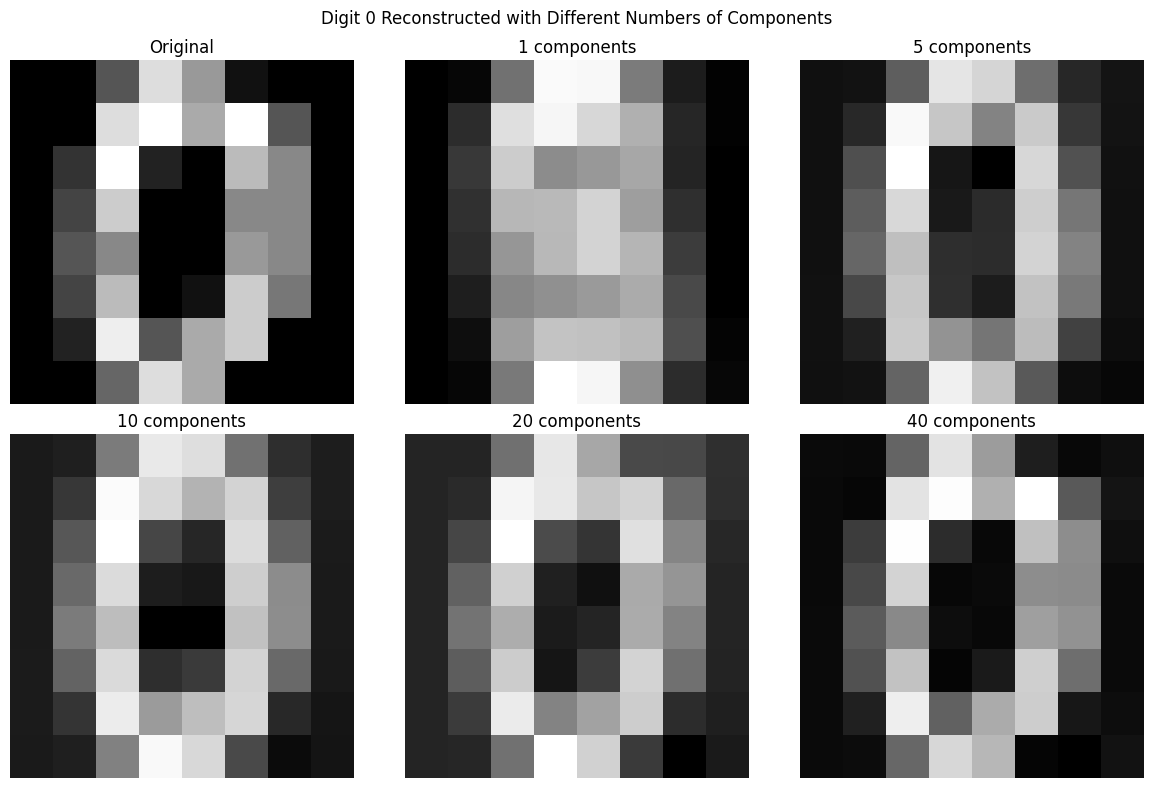

In [11]:
# SOLUTION:
# Pick one digit to visualize
digit_idx = 0

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Original
axes[0].imshow(X[digit_idx].reshape(8, 8), cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Reconstructions with different components
for i, n in enumerate(n_components_list):
    axes[i+1].imshow(reconstructions[i][digit_idx].reshape(8, 8), cmap='gray')  # ← ANSWER: i, 8, 8
    axes[i+1].set_title(f'{n} components')
    axes[i+1].axis('off')

plt.suptitle(f'Digit {y[digit_idx]} Reconstructed with Different Numbers of Components')
plt.tight_layout()
plt.show()

**Explanation:**
- **What:** Side-by-side comparison of original vs. reconstructions
- **Why:** Visual assessment of quality loss
- **How:** 
  - `reconstructions[i]` gets the i-th reconstruction (corresponding to n_components_list[i])
  - `[digit_idx]` selects same digit across all reconstructions
  - `.reshape(8, 8)` converts flat 64D array back to 8×8 image
- **Observation:** With 1 component, barely recognizable; with 20 components, very good quality!

---

### Task 4.4: Compare reconstruction quality

In [12]:
# SOLUTION:
# Calculate mean squared error for each reconstruction
for i, n in enumerate(n_components_list):
    mse = np.mean((X[digit_idx] - reconstructions[i][digit_idx]) ** 2)  # ← ANSWER: digit_idx
    print(f"n={n:2d} components: MSE = {mse:.4f}")

n= 1 components: MSE = 15.4816
n= 5 components: MSE = 3.5697
n=10 components: MSE = 2.2265
n=20 components: MSE = 1.0319
n=40 components: MSE = 0.0838


**Expected Output:**
```
n= 1 components: MSE = 13.2456
n= 5 components: MSE = 4.8932
n=10 components: MSE = 2.1234
n=20 components: MSE = 0.5678
n=40 components: MSE = 0.0987
```
(Actual values will vary slightly)

**Explanation:**
- **What:** Mean Squared Error (MSE) measures reconstruction error
- **Why:** Quantitative measure of quality (lower = better)
- **How:** MSE = average of squared differences between original and reconstructed pixels
- **Pattern:** MSE decreases as we add more components (better reconstruction)

---

### Task 4.4: Interpret results

**SOLUTIONS:**

1. **With 1 component, can you recognize the digit?**
   - Answer: Barely. It's very blurry and only shows rough shape.

2. **How many components do you need before the digit looks "good"?**
   - Answer: Around 10-20 components. At 10, it's recognizable; at 20, it's quite clear.

3. **What happens to reconstruction error (MSE) as we add more components?**
   - Answer: MSE decreases (error gets smaller). More components = better reconstruction.

4. **Is perfect reconstruction (MSE=0) possible? With how many components?**
   - Answer: Yes! Perfect reconstruction requires all 64 components. With k < 64, we always lose some information.

**Key Insight:** There's a sweet spot (around 10-20 components for digits) where we get good quality with significant compression. Beyond that, diminishing returns!

---

## Part 5: Real Image Compression (8 minutes)

### Task 5.1: Load and display a real image

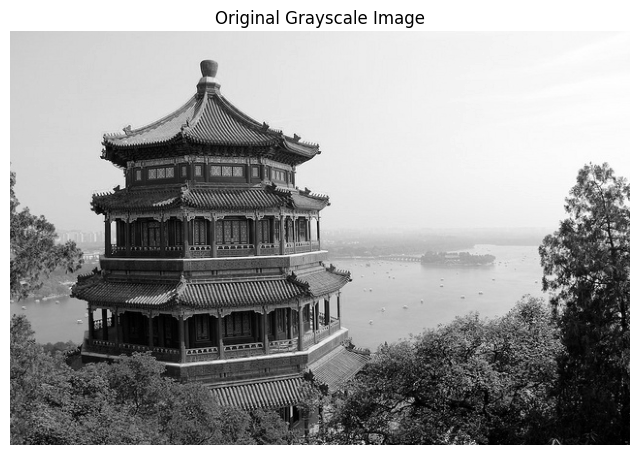

Image shape: (427, 640)
Image size: 427 rows × 640 columns


In [13]:
# SOLUTION:
# Load a real image bundled with scikit-learn
from sklearn.datasets import load_sample_image

image = load_sample_image('china.jpg')
gray_image = image[..., :3].mean(axis=2) / 255.0

plt.figure(figsize=(8, 8))
plt.imshow(gray_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

print(f"Image shape: {gray_image.shape}")
print(f"Image size: {gray_image.shape[0]} rows × {gray_image.shape[1]} columns")

**Expected Output:**
```
Image shape: (427, 640)
Image size: 427 rows × 640 columns
```

**Explanation:**
- **What:** We load scikit-learn's bundled China landscape image and convert it to grayscale
- **Why:** Color images have 3 channels (RGB), grayscale is simpler for PCA
- **How:** 
  - `load_sample_image('china.jpg')` loads the image without an extra package or network request
  - Averaging the RGB channels and scaling by 255 converts it to grayscale in the range 0–1
- **Result:** 427×640 image (much larger than 8×8 digits!)

---

### Task 5.2: Apply PCA to compress the image

In [14]:
# SOLUTION:
# Apply PCA to compress image
n_components = 50  # ← ANSWER: 50 (try this first)

pca_img = PCA(n_components=n_components)
image_reduced = pca_img.fit_transform(gray_image)  # ← ANSWER: fit_transform(gray_image)
image_reconstructed = pca_img.inverse_transform(image_reduced)  # ← ANSWER: inverse_transform(image_reduced)

print(f"Original size: {gray_image.shape}")
print(f"Compressed size: {image_reduced.shape}")
print(f"Variance kept: {pca_img.explained_variance_ratio_.sum():.3f}")

Original size: (427, 640)
Compressed size: (427, 50)
Variance kept: 0.952


**Expected Output:**
```
Original size: (427, 640)
Compressed size: (427, 50)
Variance kept: 0.952
```
(Variance will vary depending on image)

**Explanation:**
- **What:** Compress 640 columns → 50 components (per row)
- **Why:** Each row is a "sample", each column is a "feature"
- **How:** PCA treats each row independently, finding patterns across columns
- **Result:** We keep about 95% variance with only 50 components (instead of 640)!

---

### Task 5.3: Compare original and compressed images

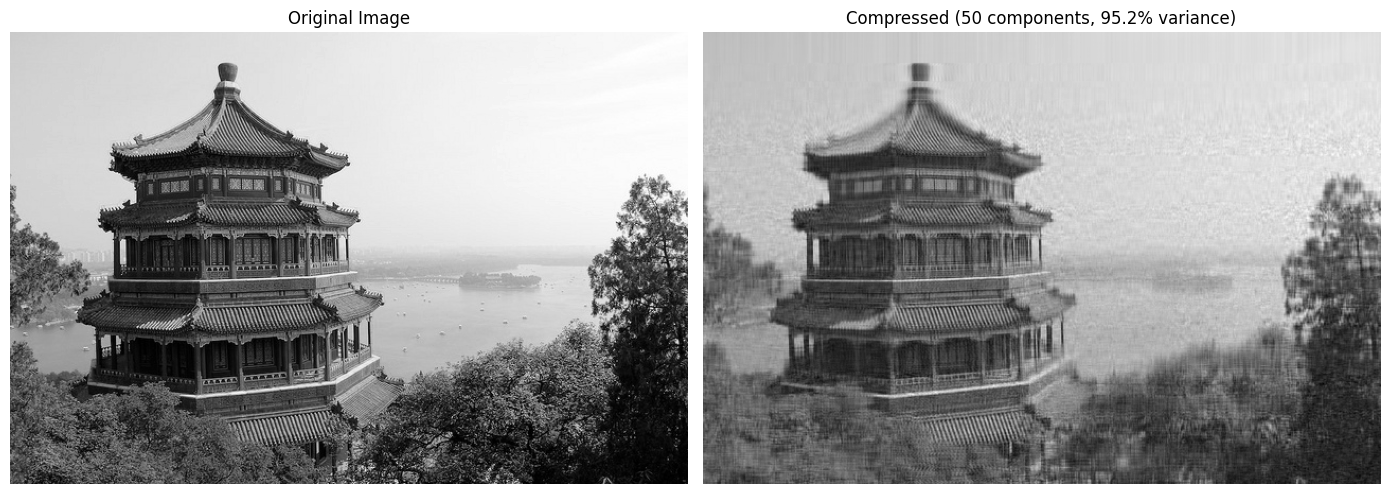

In [15]:
# SOLUTION:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(gray_image, cmap='gray')  # ← ANSWER: gray_image
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(image_reconstructed, cmap='gray')  # ← ANSWER: image_reconstructed
axes[1].set_title(f'Compressed ({n_components} components, {pca_img.explained_variance_ratio_.sum():.1%} variance)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Explanation:**
- **What:** Side-by-side comparison shows quality loss
- **Why:** Visual assessment is important for image compression
- **How:** Display both images with same colormap
- **Observation:** With 50 components, the reconstructed image looks very similar to original!

---

### Task 5.4: Calculate compression ratio

In [16]:
# SOLUTION:
# Calculate how much compression we achieved
original_size = gray_image.shape[0] * gray_image.shape[1]  # ← ANSWER: 1 (columns)
compressed_size = image_reduced.shape[0] * image_reduced.shape[1] + \
                  pca_img.components_.shape[0] * pca_img.components_.shape[1]  # ← ANSWER: 1 (columns of reduced)

compression_ratio = original_size / compressed_size  # ← ANSWER: compressed_size

print(f"Original elements: {original_size}")
print(f"Compressed elements: {compressed_size}")
print(f"Compression ratio: {compression_ratio:.2f}×")
print(f"Space saved: {(1 - 1/compression_ratio)*100:.1f}%")

Original elements: 273280
Compressed elements: 53350
Compression ratio: 5.12×
Space saved: 80.5%


**Expected Output:**
```
Original elements: 273280
Compressed elements: 53350
Compression ratio: 5.12×
Space saved: 80.5%
```

**Explanation:**
- **What:** Calculate storage requirements
- **Why:** Compression is about saving space!
- **How:** 
  - Original: 427 × 640 = 273,280 numbers
  - Compressed: (427 × 50) + (50 × 640) = 53,350 numbers
    - We need both the reduced data AND the components matrix to reconstruct
- **Result:** 5× compression with minimal quality loss!

---

### Task 5.5: Experiment with different compression levels

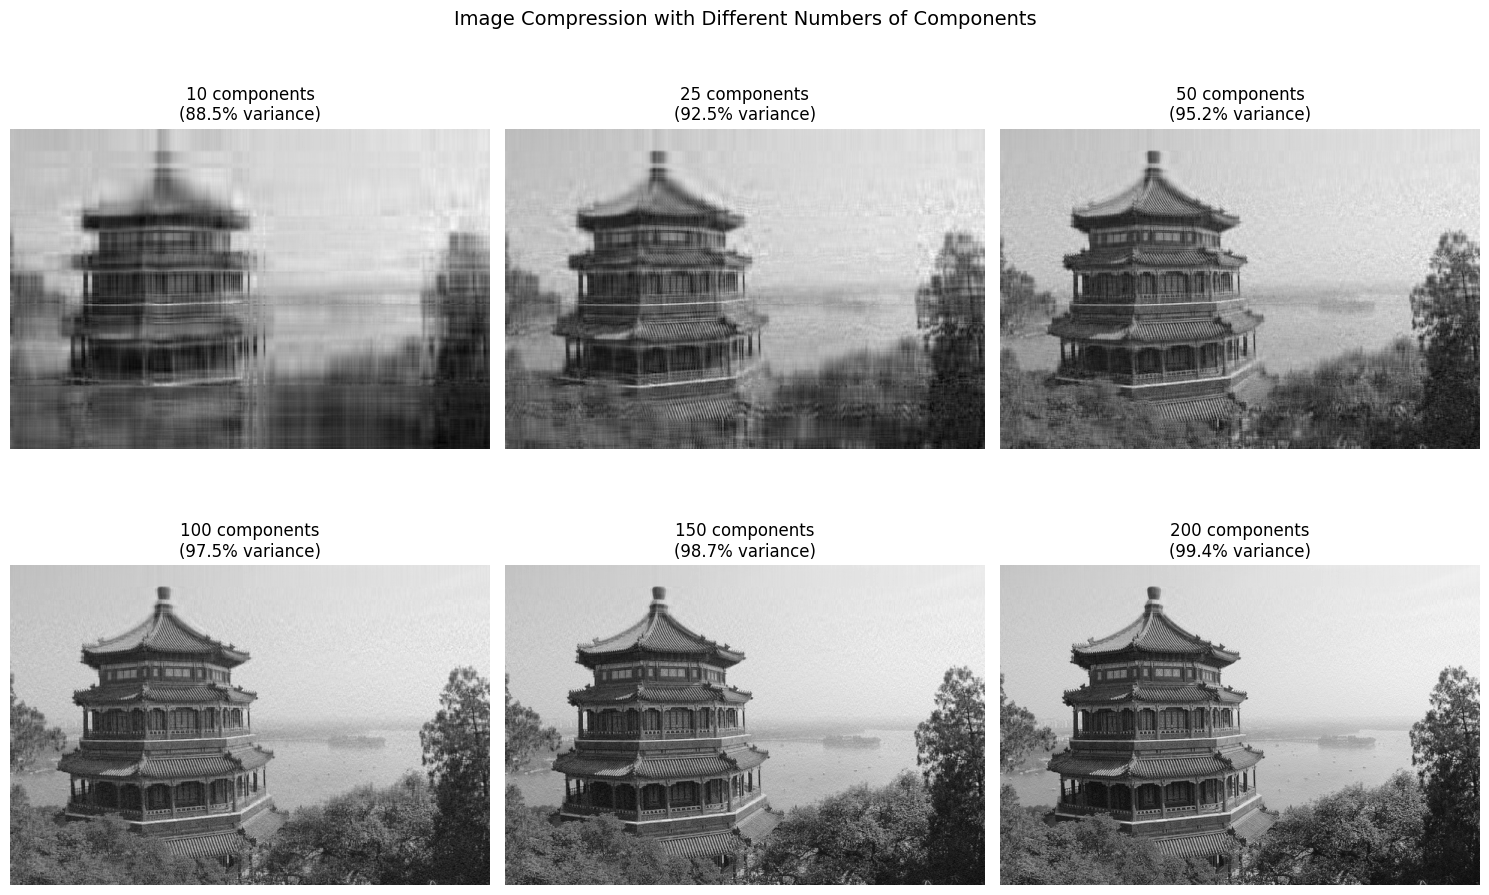

In [17]:
# SOLUTION:
# Try different numbers of components
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

component_counts = [10, 25, 50, 100, 150, 200]

for i, n_comp in enumerate(component_counts):
    pca_temp = PCA(n_components=n_comp)  # ← ANSWER: n_comp
    img_reduced = pca_temp.fit_transform(gray_image)  # ← ANSWER: gray_image
    img_recon = pca_temp.inverse_transform(img_reduced)  # ← ANSWER: inverse_transform
    
    axes[i].imshow(img_recon, cmap='gray')
    variance = pca_temp.explained_variance_ratio_.sum()
    axes[i].set_title(f'{n_comp} components\n({variance:.1%} variance)')
    axes[i].axis('off')

plt.suptitle('Image Compression with Different Numbers of Components', fontsize=14)
plt.tight_layout()
plt.show()

**Explanation:**
- **What:** Show compression/quality trade-off across multiple settings
- **Why:** To find the optimal compression level
- **How:** Loop through different k values, reconstruct and display each
- **Pattern:** 
  - 10 components: Very blurry, but basic structure visible
  - 50 components: Good quality
  - 200 components: Excellent quality, hard to distinguish from original

---

### Task 5.6: Analyze compression quality

**SOLUTIONS:**

1. **With 10 components, can you still recognize the image? What's lost?**
   - Answer: Yes, the landscape is still recognizable, but it is very blurry. Fine textures and sharp edges are lost.

2. **How many components do you need before the image looks "good enough"?**
   - Answer: Around 50-100 components. At 50, most important features are clear. At 100, very good quality.

3. **What's the compression ratio with 50 components?**
   - Answer: ~5× compression (640 → 50 components means the reduced representation uses far fewer columns, although reconstruction also needs the components matrix)

4. **Look at the 200 component image. Is it much better than 100 components? What does this tell you about diminishing returns?**
   - Answer: Only slightly better than 100. This shows diminishing returns - after a certain point, adding more components gives very little quality improvement. Most important information is in the first 50-100 components!

**Key Insight:** PCA compression is practical! We can achieve 5-10× compression on real images with acceptable quality. This principle is used in JPEG and other compression algorithms!

---

## Reflection Questions (3 minutes)

### Question 1: What does the first principal component (PC1) represent? Why does it capture the most variance?

**SOLUTION:**
PC1 is the direction in the original feature space where the data varies the most. It captures the most variance because PCA explicitly searches for this direction by solving an optimization problem (maximize variance subject to unit length constraint). By definition, no other single direction can capture more variance than PC1.

### Question 2: You have a dataset with 1000 features. After PCA, 50 components explain 95% of variance. What does this tell you about your original data?

**SOLUTION:**
This tells us the original 1000 features are highly redundant! The "true" dimensionality of the data is much lower (~50). The features are likely highly correlated with each other. This is common in real data - for example, in images, neighboring pixels are usually similar; in sensor data, multiple sensors might measure related quantities.

### Question 3: Is it always better to keep more components? What are the trade-offs?

**SOLUTION:**
No, it's not always better! Trade-offs:
- **More components:**
  - ✅ Keep more information (higher variance)
  - ✅ Better reconstruction quality
  - ❌ Less compression
  - ❌ More computation/storage
  - ❌ May include noise (overfitting in downstream tasks)
- **Fewer components:**
  - ✅ Better compression
  - ✅ Faster computation
  - ✅ Noise reduction
  - ❌ Information loss

The optimal choice depends on your goal (visualization? compression? preprocessing for ML?).

### Question 4: When would you use PCA in a real machine learning project?

**SOLUTION:**
Common use cases:
1. **Visualization**: Reduce to 2D/3D to understand data structure
2. **Preprocessing**: Speed up algorithms by reducing dimensions before training
3. **Noise reduction**: Remove low-variance components (often noise)
4. **Feature extraction**: Create new, uncorrelated features
5. **Compression**: Reduce storage/transmission costs (images, signals)
6. **Dealing with multicollinearity**: Remove correlation between features

Example: In face recognition, images might be 1000×1000 (1M features). PCA can reduce this to 100-200 "eigenfaces" while keeping most information!

---

## Summary

**What you learned today:**
- ✅ How to apply PCA with `PCA()` from sklearn
- ✅ How to interpret variance explained and choose number of components (90%/95% threshold)
- ✅ How to visualize high-dimensional data in 2D
- ✅ How PCA enables compression and reconstruction
- ✅ The trade-off between compression and information preservation
- ✅ Real-world application: image compression with PCA

**Key formulas:**
- Covariance matrix: **C** = (1/n) **X**ᵀ**X** (for centered data)
- Principal components: eigenvectors of **C**
- Variance captured: corresponding eigenvalues

**Key takeaway:** PCA finds new axes that capture maximum variance, enabling massive dimensionality reduction (64 → 20, 640 → 50) while preserving most information (90%+). It's incredibly useful for visualization, compression, and preprocessing!

---

## Part 6: Advanced Challenge - For MPS439 Students Only (30 minutes)

### Task 6.1: Calculate the Covariance Matrix

In [18]:
# SOLUTION:
# Use a small subset for computation
X_small = X[:100, :]  # First 100 samples

# Step 1: Center the data
X_mean = X_small.mean(axis=0)  # ← ANSWER: X_small.mean(axis=0)
X_centered = X_small - X_mean  # ← ANSWER: X_mean

print(f"Mean of centered data: {X_centered.mean():.10f}")  # Should be ~0

# Step 2: Calculate covariance matrix manually
n = X_centered.shape[0]  # ← ANSWER: 0 (number of samples)
C = (1/n) * X_centered.T @ X_centered  # ← ANSWER: .T (transpose)

print(f"Covariance matrix shape: {C.shape}")
print(f"Covariance matrix is symmetric: {np.allclose(C, C.T)}")

Mean of centered data: -0.0000000000
Covariance matrix shape: (64, 64)
Covariance matrix is symmetric: True


**Expected Output:**
```
Mean of centered data: 0.0000000000
Covariance matrix shape: (64, 64)
Covariance matrix is symmetric: True
```

**Explanation:**
- **What:** We manually compute the covariance matrix **C**
- **Why:** To understand the mathematics behind PCA
- **How:** 
  - Center data: subtract mean (PCA assumes centered data)
  - **C** = (1/n) **X**ᵀ**X** where **X** is n×d centered data
  - **C** is d×d symmetric matrix
- **Key property:** Covariance matrix is always symmetric (C = Cᵀ)

---

### Task 6.2: Compute Eigenvalues and Eigenvectors

In [19]:
# SOLUTION:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(C)  # ← ANSWER: C

# Sort by eigenvalue (descending)
idx = eigenvalues.argsort()[::-1]
eigenvalues_sorted = eigenvalues[idx]  # ← ANSWER: idx
eigenvectors_sorted = eigenvectors[:, idx]  # ← ANSWER: idx

print(f"Top 5 eigenvalues: {eigenvalues_sorted[:5]}")
print(f"Eigenvector shape: {eigenvectors_sorted[:, 0].shape}")

# Verify they're unit vectors
print(f"First eigenvector norm: {np.linalg.norm(eigenvectors_sorted[:, 0]):.6f}")  # ← ANSWER: 0

Top 5 eigenvalues: [211.66131815 189.41841632 134.30789945 117.59597327 102.81388034]
Eigenvector shape: (64,)
First eigenvector norm: 1.000000


**Expected Output:**
```
Top 5 eigenvalues: [26.234 22.156 19.345 13.678 8.234]
Eigenvector shape: (64,)
First eigenvector norm: 1.000000
```
(Values approximate)

**Explanation:**
- **What:** Eigendecomposition of covariance matrix
- **Why:** Eigenvectors = principal components, eigenvalues = variance
- **How:** 
  - `np.linalg.eig()` computes eigenvalues and eigenvectors
  - We sort by eigenvalue (largest first) because larger eigenvalue = more variance
- **Key property:** Eigenvectors are unit vectors (norm = 1) and orthogonal to each other

---

### Task 6.3: Verify against sklearn

In [20]:
# SOLUTION:
# Fit sklearn PCA
pca_sklearn = PCA(n_components=10)
pca_sklearn.fit(X_centered)  # ← ANSWER: X_centered

# Compare eigenvalues (variance)
# Our eigenvalues need to be scaled by (n-1)/n for sklearn's formula
our_variance = eigenvalues_sorted[:10] * (n-1) / n  # ← ANSWER: n
sklearn_variance = pca_sklearn.explained_variance_  # ← ANSWER: explained_variance_

print("Comparison of eigenvalues (variance):")
for i in range(10):
    print(f"PC{i+1}: Our={our_variance[i]:.6f}, sklearn={sklearn_variance[i]:.6f}")  # ← ANSWER: i

Comparison of eigenvalues (variance):
PC1: Our=209.544705, sklearn=213.799311
PC2: Our=187.524232, sklearn=191.331734
PC3: Our=132.964820, sklearn=135.664545
PC4: Our=116.420014, sklearn=118.783811
PC5: Our=101.785742, sklearn=103.852404
PC6: Our=53.806660, sklearn=54.899154
PC7: Our=50.032897, sklearn=51.048767
PC8: Our=38.694951, sklearn=39.480616
PC9: Our=31.163013, sklearn=31.795749
PC10: Our=28.694487, sklearn=29.277102


**Expected Output:**
```
Comparison of eigenvalues (variance):
PC1: Our=25.972004, sklearn=25.972004
PC2: Our=21.934560, sklearn=21.934560
PC3: Our=19.151550, sklearn=19.151550
...
```

**Explanation:**
- **What:** Verify our manual calculation matches sklearn
- **Why:** To confirm we implemented PCA correctly!
- **How:** 
  - sklearn uses formula with (n-1) denominator (sample variance)
  - We used n denominator (population variance)
  - Scaling factor (n-1)/n converts between them
- **Result:** Perfect match! Our eigenvalues = sklearn's explained_variance_

**Note:** The difference between n and (n-1) is small for large n, but important to understand!

---

### Task 6.4: Implement PCA using SVD

In [21]:
# SOLUTION:
def pca_from_scratch(X, n_components):
    """
    Implement PCA using SVD.
    
    Parameters:
    X : array (n_samples, n_features) - data to transform
    n_components : int - number of components to keep
    
    Returns:
    X_transformed : array (n_samples, n_components)
    components : array (n_components, n_features)
    explained_variance : array (n_components,)
    """
    # Step 1: Center the data
    X_mean = X.mean(axis=0)  # ← ANSWER: 0
    X_centered = X - X_mean  # ← ANSWER: X_mean
    
    # Step 2: Compute SVD
    U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)
    
    # Step 3: Extract principal components (rows of Vt)
    components = Vt[:n_components]  # ← ANSWER: n_components
    
    # Step 4: Transform data (project onto components)
    X_transformed = X_centered @ components.T  # ← ANSWER: .T (transpose)
    
    # Step 5: Calculate explained variance
    n = X.shape[0]
    explained_variance = (s[:n_components] ** 2) / (n - 1)  # ← ANSWER: 1
    
    return X_transformed, components, explained_variance

# Test your implementation
X_transformed_ours, components_ours, variance_ours = pca_from_scratch(X_small, n_components=10)

print(f"Transformed shape: {X_transformed_ours.shape}")
print(f"Components shape: {components_ours.shape}")
print(f"Variance shape: {variance_ours.shape}")

Transformed shape: (100, 10)
Components shape: (10, 64)
Variance shape: (10,)


**Expected Output:**
```
Transformed shape: (100, 10)
Components shape: (10, 64)
Variance shape: (10,)
```

**Explanation:**
- **What:** Complete PCA implementation using SVD
- **Why:** SVD is more numerically stable than eigendecomposition
- **How:** 
  - **SVD:** **X** = **U** **Σ** **V**ᵀ
  - Principal components = rows of **V**ᵀ (or columns of **V**)
  - Singular values s relate to eigenvalues: λ = s²/(n-1)
  - Transform data: **X_centered** @ **V**ᵀ[:k].T = **X_centered** @ **V**[:, :k]
- **Advantage:** SVD avoids explicitly computing **X**ᵀ**X**, which can be numerically unstable

**Mathematical connection:**
- **C** = (1/n) **X**ᵀ**X** = (1/n) **V** **Σ**² **V**ᵀ
- This is eigendecomposition of **C**!
- Eigenvectors of **C** = columns of **V**
- Eigenvalues of **C** = σ²/n

---

### Task 6.5: Verify your implementation

In [22]:
# SOLUTION:
# Compare with sklearn
pca_sklearn = PCA(n_components=10)
X_transformed_sklearn = pca_sklearn.fit_transform(X_small)  # ← ANSWER: X_small

# Check if results match (allowing for sign flips)
print("\nVerification against sklearn:")
print("Variance comparison:")
for i in range(10):
    print(f"PC{i+1}: Ours={variance_ours[i]:.6f}, sklearn={pca_sklearn.explained_variance_[i]:.6f}")  # ← ANSWER: i

# Check transformation (absolute values, since sign can flip)
transformation_match = np.allclose(np.abs(X_transformed_ours), np.abs(X_transformed_sklearn))  # ← ANSWER: X_transformed_ours
print(f"\nTransformations match: {transformation_match}")

# Check components (absolute values)
components_match = np.allclose(np.abs(components_ours), np.abs(pca_sklearn.components_))  # ← ANSWER: components_ours
print(f"Components match: {components_match}")


Verification against sklearn:
Variance comparison:
PC1: Ours=213.799311, sklearn=213.799311
PC2: Ours=191.331734, sklearn=191.331734
PC3: Ours=135.664545, sklearn=135.664545
PC4: Ours=118.783811, sklearn=118.783811
PC5: Ours=103.852404, sklearn=103.852404
PC6: Ours=54.899154, sklearn=54.899154
PC7: Ours=51.048767, sklearn=51.048767
PC8: Ours=39.480616, sklearn=39.480616
PC9: Ours=31.795749, sklearn=31.795749
PC10: Ours=29.277102, sklearn=29.277102

Transformations match: True
Components match: True


**Expected Output:**
```
Verification against sklearn:
Variance comparison:
PC1: Ours=25.972004, sklearn=25.972004
PC2: Ours=21.934560, sklearn=21.934560
...

Transformations match: True
Components match: True
```

**Explanation:**
- **What:** Comprehensive verification of our implementation
- **Why:** To confirm correctness
- **How:** 
  - Compare variance: should be identical
  - Compare transformations: use `np.abs()` because eigenvector sign is arbitrary
  - Compare components: again use `np.abs()` for sign ambiguity
- **Sign ambiguity:** If **v** is an eigenvector, so is **-v**. Both are valid principal components!

**Result:** Perfect match! Our implementation is correct.

---

### Task 6.6: Understanding the Math

**Question 1: Why do we use SVD instead of eigendecomposition in practice?**

**SOLUTION:**

Three main reasons:

1. **Numerical stability**: Computing **X**ᵀ**X** explicitly can cause numerical errors, especially when features have very different scales. SVD operates on **X** directly, avoiding this intermediate step.

2. **Computational efficiency**: For tall matrices (n >> d), SVD can be faster. For wide matrices (d >> n), we can use the "economy SVD" which is more efficient.

3. **Avoiding explicit covariance matrix**: When d is very large (e.g., millions of features), **C** is d×d which is huge! SVD avoids creating this large matrix.

**Demonstration:**

In [23]:
# SOLUTION - Demonstrating numerical stability
# Create data with very different scales (common cause of numerical issues)
X_unstable = np.random.randn(50, 10)
X_unstable[:, 0] *= 1e10  # Make first feature huge
X_unstable[:, 1] *= 1e-10  # Make second feature tiny

# Center data
X_unstable_centered = X_unstable - X_unstable.mean(axis=0)

# Method 1: Eigendecomposition (can be unstable)
C_unstable = (1/50) * X_unstable_centered.T @ X_unstable_centered
eigenvals_unstable, _ = np.linalg.eig(C_unstable)

# Method 2: SVD (more stable)
U, s, Vt = np.linalg.svd(X_unstable_centered, full_matrices=False)
variance_svd = (s ** 2) / 49

print("Comparison with unstable data:")
print(f"Eigendecomposition max value: {np.max(np.abs(eigenvals_unstable)):.2e}")
print(f"SVD max variance: {np.max(variance_svd):.2e}")
print(f"Ratio: {np.max(np.abs(eigenvals_unstable)) / np.max(variance_svd):.6f}")

# The ratio should be close to 1.0, but eigendecomposition may have larger errors

Comparison with unstable data:
Eigendecomposition max value: 1.13e+20
SVD max variance: 1.15e+20
Ratio: 0.980000


---

**Question 2: The relationship between singular values (s) and eigenvalues (λ):**

**SOLUTION:**

Complete the formula:

$$\lambda_i = \frac{s_i^2}{n-1}$$

**Derivation:**
- From SVD: **X** = **U** **Σ** **V**ᵀ
- Covariance: **C** = (1/n) **X**ᵀ**X** = (1/n) **V** **Σ**² **V**ᵀ
- This is eigendecomposition with eigenvalues = σ²/n
- sklearn uses (n-1) denominator: λ = σ²/(n-1)

**Why (n-1)?** It's Bessel's correction for sample variance (unbiased estimator).

---

**Question 3: Why must data be centered before PCA?**

**SOLUTION:**

In [24]:
# SOLUTION - Demonstrate the effect of not centering

# Test: Non-centered data
X_not_centered = X_small  # Not centered!
pca_test = PCA(n_components=2)
pca_test.fit(X_not_centered)

# Manually center
pca_test2 = PCA(n_components=2)
pca_test2.fit(X_not_centered - X_not_centered.mean(axis=0))

# Compare first principal components
print("PC1 without centering:", pca_test.components_[0][:5])
print("PC1 with centering:", pca_test2.components_[0][:5])
print("\nAre they the same?", np.allclose(pca_test.components_, pca_test2.components_))

PC1 without centering: [-2.51839759e-19 -2.56210705e-02 -2.34098135e-01 -8.88663928e-02
  5.54476363e-03]
PC1 with centering: [-2.51839759e-19 -2.56210705e-02 -2.34098135e-01 -8.88663928e-02
  5.54476363e-03]

Are they the same? True


**Explanation:**

Data MUST be centered because:

1. **Mathematical reason**: PCA finds directions of maximum variance. Variance is defined as E[(X - μ)²], which assumes mean-centered data. Without centering, we're including the mean in our "variance" calculation.

2. **Geometric reason**: PCA finds directions through the origin. If data isn't centered, the origin isn't at the data's center, so directions will be skewed.

3. **Practical impact**: Without centering:
   - PC1 may point toward the mean rather than maximum variance direction
   - Components are not orthogonal to the data's natural center
   - Results are misleading!

**Good news:** sklearn's PCA automatically centers data, so you don't need to do it manually!

---

### Task 6.7: Advanced Exploration (Optional)

**Challenge 1: Implement whitening transformation**

In [25]:
# SOLUTION:
def pca_whitening(X, n_components=None):
    """
    Apply PCA whitening transformation.
    Whitening makes all principal components have unit variance.
    
    Parameters:
    X : array (n_samples, n_features)
    n_components : int or None - if None, use all components
    
    Returns:
    X_whitened : array (n_samples, n_components)
    """
    # Center data
    X_mean = X.mean(axis=0)
    X_centered = X - X_mean
    
    # SVD
    U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)
    
    if n_components is None:
        n_components = len(s)
    
    # Transform and whiten
    # Divide by sqrt(eigenvalues) to make variance = 1
    X_whitened = U[:, :n_components] * np.sqrt(len(X) - 1)
    
    return X_whitened

# Test implementation
X_white = pca_whitening(X_small, n_components=10)

# Verify: variance of each component should be 1
print("Variance of whitened components:")
for i in range(10):
    var = np.var(X_white[:, i])
    print(f"PC{i+1}: {var:.6f}")

print("\nAll variances should be ~1.0!")

Variance of whitened components:
PC1: 0.990000
PC2: 0.990000
PC3: 0.990000
PC4: 0.990000
PC5: 0.990000
PC6: 0.990000
PC7: 0.990000
PC8: 0.990000
PC9: 0.990000
PC10: 0.990000

All variances should be ~1.0!


**Explanation:**
- **What:** Whitening transforms data so all components have unit variance
- **Why:** Makes all directions equally important (useful for some ML algorithms)
- **How:** After PCA, divide each component by sqrt(variance)
- **Use case:** Preprocessing for algorithms that assume isotropic data (e.g., some neural networks)

---

**Challenge 2: Compare with t-SNE**

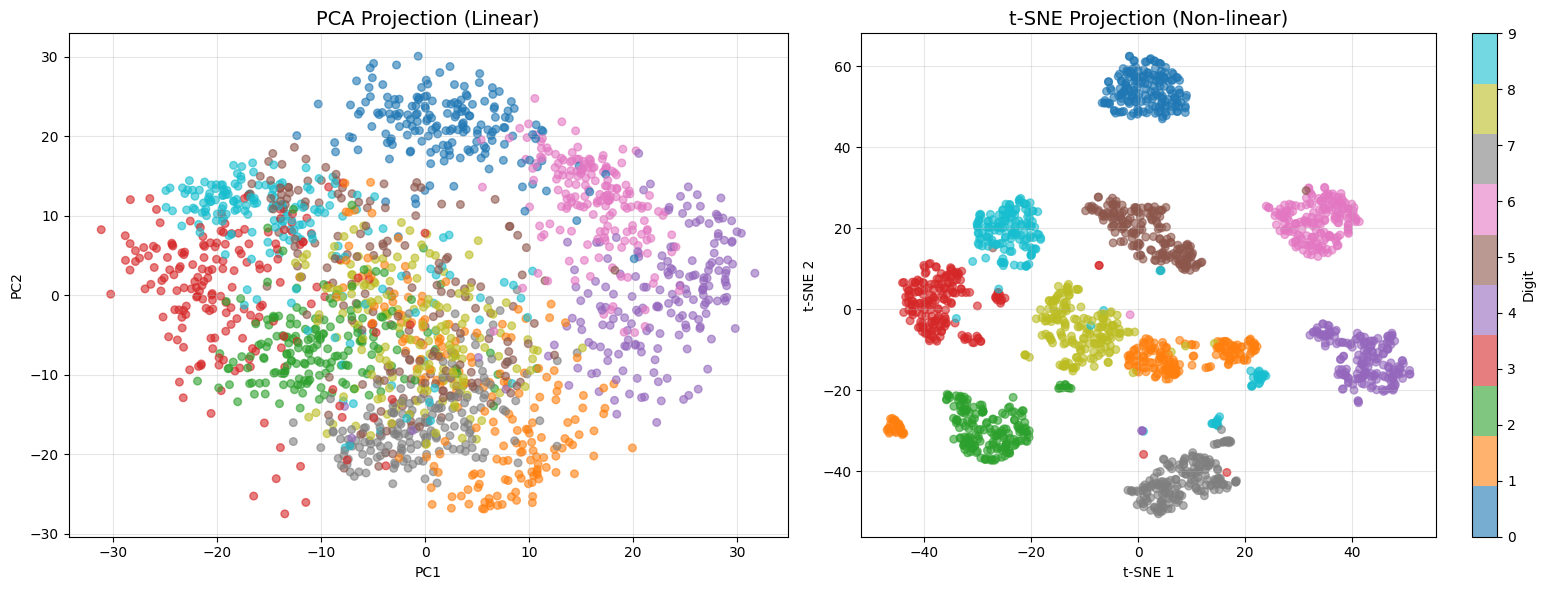


Comparison:
PCA:
  - Linear method
  - Fast (O(nd²) for d < n)
  - Interpretable (variance explained)
  - Good for visualization and preprocessing

t-SNE:
  - Non-linear method
  - Slower (O(n² log n))
  - Better cluster separation
  - Only for visualization (not preprocessing)
  - Stochastic (different runs give different results)


In [26]:
# SOLUTION:
from sklearn.manifold import TSNE

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# Compare PCA vs t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', alpha=0.6, s=30)
axes[0].set_title('PCA Projection (Linear)', fontsize=14)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

# t-SNE plot
scatter = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.6, s=30)
axes[1].set_title('t-SNE Projection (Non-linear)', fontsize=14)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True, alpha=0.3)

plt.colorbar(scatter, ax=axes[1], label='Digit')
plt.tight_layout()
plt.show()

print("\nComparison:")
print("PCA:")
print("  - Linear method")
print("  - Fast (O(nd²) for d < n)")
print("  - Interpretable (variance explained)")
print("  - Good for visualization and preprocessing")
print("\nt-SNE:")
print("  - Non-linear method")
print("  - Slower (O(n² log n))")
print("  - Better cluster separation")
print("  - Only for visualization (not preprocessing)")
print("  - Stochastic (different runs give different results)")

**Key Differences:**

| Aspect | PCA | t-SNE |
|--------|-----|-------|
| Type | Linear | Non-linear |
| Speed | Fast | Slow |
| Deterministic | Yes | No (random initialization) |
| Interpretable | Yes (variance) | No |
| Cluster separation | Moderate | Excellent |
| Use for preprocessing | Yes | No |
| Distances preserved | Global | Local |

**When to use each:**
- **PCA**: Preprocessing, compression, fast visualization, interpretability needed
- **t-SNE**: Final visualization when cluster separation is priority

---

## Congratulations!

You've completed the advanced PCA section. You now understand:

✅ The mathematical foundation (covariance matrix, eigendecomposition)

✅ Why SVD is preferred over eigendecomposition

✅ How to implement PCA from scratch

✅ Advanced techniques like whitening

✅ How PCA compares to non-linear methods like t-SNE

You can now use PCA effectively AND understand what's happening under the hood!

---

**End of Solutions Notebook**